In [1]:
import os
import numpy as np
import pickle
# from qiskit.quantum_info import Statevector

# File imports
from qae import *
# from resource_estimator import *
import ExpValFun_functions as exp
from binary_optimizer import *

%load_ext autoreload
%autoreload 2

# Running the quantum expected value function algorithm
This notebook will walk through how to use the code, as it is on September 6 2024, to compute the expected value function with a quantum algorithm. The two stage objective function has the form 
$$ \min_x o(x) := f(x) + \mathbb{E}_\xi [Q(x,\xi)]$$
where $\phi(x) \equiv \mathbb{E}_\xi [Q(x,\xi)]$ is computed on the quantum computer.

We will focus on a problem inspired by the power grid, with $n_y$ wind turbines labeled from $0$ to $n_y-1$ and a single gas generator $x$. Each wind turbine can be 'off' or 'on', conditional on whether the wind is blowing at that turbine's location. $\xi$ is the random variable, and $\xi_i \in \{0,1\}$ is $0$ when the wind does _not_ blow and $1$ otherwise at turbine $i$. If total power demand is $d$, the cost of using a resource is $c$, and $r$ represents the penalty of not satisfying demand, we get the objective function:

$$ \min_{x \in \mathbb{Z}_{\geq 0}} o(x) := c_xx + \mathbb{E}_\xi[Q(x,\xi)] $$

$$ Q(x,\xi) = \min_{y \in \{0,1\}^{n_y}} \sum_{i=0}^{n_y-1} c_{y,i} y_i  + c_r r$$

$$ \sum_{i=0}^{n_y-1} y_i + x = d-r $$

$$ y_i \leq \xi_i \; \forall i $$

To run through this example, we will choose 4 wind turbines that each have their own cost, sorted as the cheapest to most expensive, left to right (right to left in Qiskit order). We assume that $\xi$ is independently identically distributed (uniform distribution). We will use the `QAE_Optimizer` class to construct our problem.

First, we will create an example instance.

In [2]:
# Define variables
n_y = 4
n_xi = 4
n_x = 1
d = n_y

# Define costs
c_x = [3.,]
c_y = [0.4, 0.5, 0.7, 1.]
c_r = 10.

# Define pdf
pdf = pdf = {tuple([int(v) 
              for v in ('{0:0'+str(n_y)+'b}').format(i)
             ]) 
       : 1/2**n_y for i in range(2**n_y)}

## The example problem with classical solution.
We can compute the expected value function for each value of $x$ by calling the function `brute_force_wind_demand_expectation_values()` with the `BinaryNextedOptimizer` class. For this notebook we will call this `bf_optimizer`. This function returns a list of costs, where the index `i` in the list is the units of power the wind turbines are expected to cover and the value at that index is the expected value function with `x=d-i`.

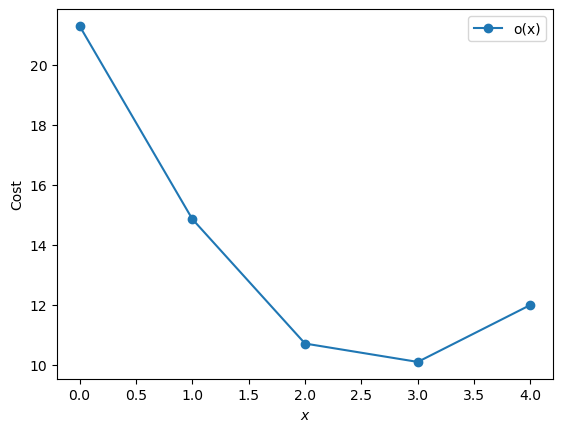

In [3]:
# create the optimizer object
bf_optimizer = BinaryNestedOptimizer(c_x, c_y, c_r, pdf, n_y, is_uniform=True)

# NOTE index i indicates the wind turbines produce 'i' units of power (implicitly, x=d-i)
exp_vals = bf_optimizer.brute_force_wind_demand_expectation_values() # for each value of d-x, compute the expectation value
bruteforce_vals = [bf_optimizer.gas_costs[0]*x + exp_vals[d-x] for x in range(d+1)] # for each x value compute the objective function

plt.xlabel(r'$x$')
plt.ylabel(r'Cost')
plt.plot(bruteforce_vals, '-o', label='o(x)')
plt.legend()
plt.show()

# Constructing Digitized Quantum Annealing
A fundamental piece of our algorithm is Digitized Quantum Annealing (DQA) using the alternating operator ansatz

$$ |x\rangle\sum_{\xi_i} \sqrt{p(\xi_i)} |y_i^*, \xi_i\rangle = \lim_{T->\infty} \Big[\prod_{t=0}^{T} e^{-ia(t/T)H_M}e^{-ib(t/T)H_C} \Big] V_S V_\xi |x,0,0\rangle$$

To better encode the problem on a quantum computer, we elect to re-write the _second state_ objective function as 
$$ Q(x,\xi) = \min_y \sum_{i=0}^{n_y-1} c_{y,i}y_i\xi_i + c_ry_i(1-\xi_i)$$
$$ x+\sum_{i=0}^{n_y-1} y_i = d$$

We construct this with the `alternating_operator_ansatz` function in the `QAE_Optimizer`. This class takes a user-specified cost operator circuit and mixer circuit and creates an alternating operator asatz circuit. It requires circuits for the initial state preparation of the $y$ qubits and initial state preparation of the $\xi$ qubits as well. Additionally, it needs a list of angles for the annealing procedure, as well as list objects representing the qubit registers for the system qubits and the pdf qubits. For a further look at these functions, they can be found in `ExpValFun_functions.py`. 

Finally, we will put all of our parameters in a dictionary to create the circuit, thus organizing our parameters. This allows us to efficiently compile our circuit.

In [4]:
# Define variables for our cost operator and mixer operator

# Qubit registers
y_reg = list(range(n_y))
pdf_reg = list(range(n_y, 2*n_y))

# Array of Theta vals for time evolution
time = 4
timesteps = 4
Theta = []
for t in range(timesteps):

        Theta.append(np.float64(t/timesteps))
        Theta.append((1-np.float64(t/timesteps))/np.pi)

# Finally, set demand and cost function norm
w_d = 2
cost_norm = 5

In [5]:
# Wrap variables in a dictionary to construct circuit

args = {
        # Variables
        'n_y':n_y,
        'n_x':n_x,
        'n_xi':n_xi,
        'c_x':c_x,
        'c_y':c_y,
        'c_r':c_r,
        'pdf':pdf,
        'y_reg':y_reg,
        'pdf_reg':pdf_reg,
        'Theta':Theta,
        'w_d':w_d,
        'cost_norm':cost_norm,
        'uniform':True,

        # Functions
        'cost_operator_circuit':exp.cost_operator, 
        'mixer_operator_circuit':exp.demand_constraint_preserving_mixer,
        'initial_state_circuit':exp.dicke_state_circuit,
        'pdf_circuit':pdf_initialize,
}

# Create alternating operator ansatz circuit

circuit = exp.alternating_operator_ansatz(args)

circuit.draw()

┌─────────────┐      ┌─────────────┐┌───────────────┐┌──────────────┐»
q_0: ─────┤0            ├──────┤0            ├┤0              ├┤0             ├»
          │             │      │             ││               ││              │»
q_1: ─────┤1            ├──────┤1            ├┤1              ├┤1             ├»
          │  DickeState │      │             ││  $U_d(0.318)$ ││              │»
q_2: ─────┤2            ├──────┤2            ├┤2              ├┤2             ├»
          │             │      │             ││               ││              │»
q_3: ─────┤3            ├──────┤3            ├┤3              ├┤3             ├»
     ┌────┴─────────────┴─────┐│  $U_q(0.0)$ │└───────────────┘│  $U_q(0.25)$ │»
q_4: ┤0                       ├┤4            ├─────────────────┤4             ├»
     │                        ││             │                 │              │»
q_5: ┤1                       ├┤5            ├─────────────────┤5             ├»
     │  $|\mathcal{P}\rangle$ ││             │                 │              │»
q_6: ┤2                       ├┤6            ├─────────────────┤6             ├»
     │                        ││             │                 │              │»
q_7: ┤3                       ├┤7            ├─────────────────┤7             ├»
     └────────────────────────┘└─────────────┘                 └──────────────┘»
«     ┌───────────────┐┌─────────────┐┌───────────────┐┌──────────────┐»
«q_0: ┤0              ├┤0            ├┤0              ├┤0             ├»
«     │               ││             ││               ││              │»
«q_1: ┤1              ├┤1            ├┤1              ├┤1             ├»
«     │  $U_d(0.239)$ ││             ││  $U_d(0.159)$ ││              │»
«q_2: ┤2              ├┤2            ├┤2              ├┤2             ├»
«     │               ││             ││               ││              │»
«q_3: ┤3              ├┤3            ├┤3              ├┤3             ├»
«     └───────────────┘│  $U_q(0.5)$ │└───────────────┘│  $U_q(0.75)$ │»
«q_4: ─────────────────┤4            ├─────────────────┤4             ├»
«                      │             │                 │              │»
«q_5: ─────────────────┤5            ├─────────────────┤5             ├»
«                      │             │                 │              │»
«q_6: ─────────────────┤6            ├─────────────────┤6             ├»
«                      │             │                 │              │»
«q_7: ─────────────────┤7            ├─────────────────┤7             ├»
«                      └─────────────┘                 └──────────────┘»
«     ┌──────────────┐
«q_0: ┤0             ├
«     │              │
«q_1: ┤1             ├
«     │  $U_d(0.08)$ │
«q_2: ┤2             ├
«     │              │
«q_3: ┤3             ├
«     └──────────────┘
«q_4: ────────────────
«                     
«q_5: ────────────────
«                     
«q_6: ────────────────
«                     
«q_7: ────────────────
«

## Fixed gas output
First, we fix total gas output to $i=2$ to assert that this wavefunction is correct. Let's run an experiment to ensure this.

To visualize what the algorithm does, we can see that each scenario (the first 4 qubits) demarcates a different wavefunction on the second register's 4 qubits (decision variables). We can also plot this: notice how the rightmost (cheapest) qubits get the $1$ states whenever possible. Also observe how the second-stage decision converges to a delta function at the best 'choice' as `t` increases. 

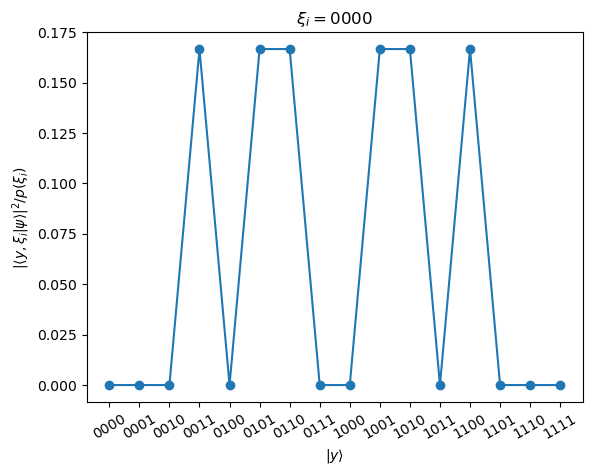

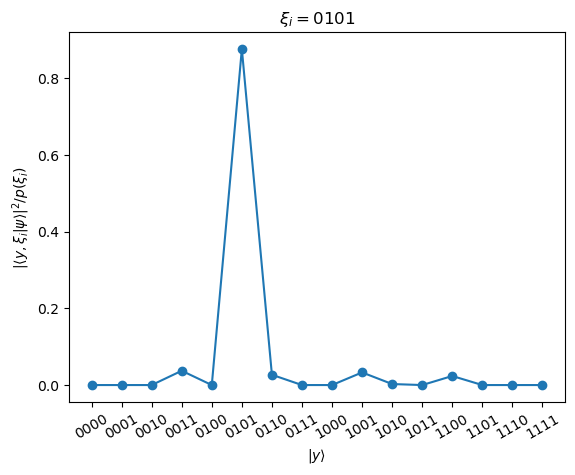

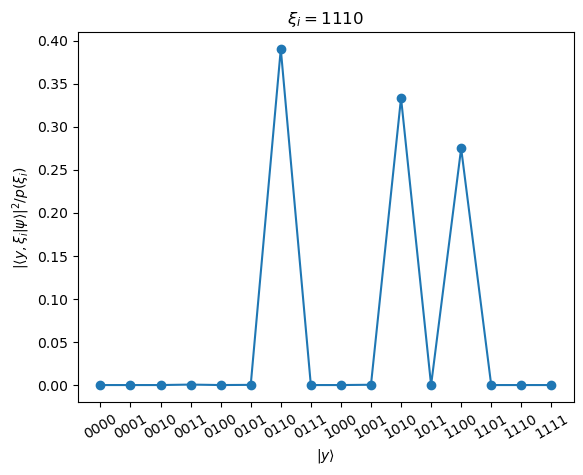

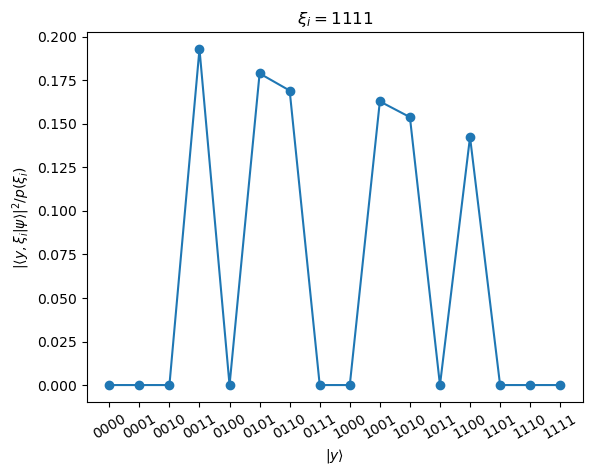

In [6]:
# get a dictionary of bitstring -> probability
sv = Statevector.from_label('0'*(n_y+n_xi))
sv = sv.evolve(circuit)
results = sv.probabilities_dict()

# create a dictionary of pdf scenario -> decision register
decisions = {}
str_scenarios = []
for scenario,pr in pdf.items():
    s = ''.join([str(x) for x in scenario])
    str_scenarios.append(s)
    decisions[s] = {}
    for bstr,pr1 in results.items():
        if bstr[:n_xi] == s:
            decisions[s][bstr[n_xi:]] = pr1/pr
            
# for each scenario, plot the objective function surface
xvals = [('{0:0' + str(n_y) + 'b}').format(s) for s in range(2**n_y)] # make a list of all possible |y> bitstrings
# just choose a few scenarios to look at the objective function surface
scenarios_plots = ['0000', '0101', '1110', '1111']
for bstr in scenarios_plots:
    yvals = [decisions[bstr][bstr2] if bstr2 in decisions[bstr].keys() else 0. for bstr2 in xvals]
    plt.plot(xvals, yvals, '-o')
    # plot parameters
    plt.xticks(rotation=30, ha='center')
    plt.xlabel(r'$|y\rangle$')
    plt.ylabel(r'$|\langle y,\xi_i | \psi \rangle|^2 / p(\xi_i)$')
    plt.title(r'$\xi_i=${}'.format(bstr))
    plt.show()

# Quantum Amplitude Estimation Class
Now we set `m` measurement qubits, and choose the oracle $\mathcal{F}_{\sin}$, which will induce some systematic error but will still be very fast. We also must choose a normalization $\text{norm}$ for the oracle such that $r*d/\text{norm}=1$. We will do this again with wind demand $=2$. We will also use the same adiabatic evolution parameters from the last section.

We will expand on the dictionary we made before by adding a few more parameters necessary to carry out QAE. Then, using the QAE class we will compile all of our ingredients into a QuantumCircuit object. We will be using the `single_oracle_sin_inconstraint` function found in the `ExpValFun_functions.py` file.

In [7]:
m = 4
norm = w_d * c_r

# We will add these, as well as our oracle function, to our args dictionary
args['m'] = m
args['norm'] = norm
args['oracle_circuit'] = exp.single_oracle_sin_inconstraint

# Finally, we will specify if we want the circuit decomposed into native gates. If you want native gates, give a list containing the qiskit gate id's.
# Otherwise, just write False

args['gateset'] = False
# args['gateset] = ['id', 'u1', 'u2', 'u3', 'cx']

# Compile circuit

optimizer = QAE_Optimizer(args)

circuit = optimizer.compile_qae_circuit()

In [8]:
# run the circuit
sv = Statevector.from_label('0'*(n_y + n_xi + m + 1))
sv = sv.evolve(circuit)

In [9]:
# measure the first m qubits
nmeas = 100 # how many times do we repeat the experiment?
results = sv.sample_counts(nmeas, qargs=list(range(m)))

avg = 0

# post process the results
for key,value in results.items():
    # get the amplitude
    amp = np.sin(int(key,2)*np.pi/2**m)**2 
    avg += amp*norm*value/nmeas
    # print('Expected value function estimate:', amp*norm)

print('Average Expected Value Function Estimate', avg)
print("True function", exp_vals[w_d])

Average Expected Value Function Estimate 5.396424056664871
True function 4.712500000000002


Alternatively, you can also load a problem from a file and use that to create the circuit. Just specify a data path to a pre-constructed Python dict and import it!

In [10]:
# prob_data_path = f'{os.getcwd()}/test_cases/wind_prob_instances'
prob_data_path = f'{os.getcwd()}'

with open(prob_data_path+'/four_binary_turbines_test.pickle', 'rb') as handle:
    args = pickle.load(handle)

optimizer = QAE_Optimizer(args)

circuit = optimizer.compile_qae_circuit()

In [11]:
# run the circuit
sv = Statevector.from_label('0'*(n_y + n_xi + m + 1))
sv = sv.evolve(circuit)

In [12]:
# measure the first m qubits
nmeas = 1 # how many times do we repeat the experiment?
results = sv.sample_counts(nmeas, qargs=list(range(m)))

# post process the results
for key,value in results.items():
    # get the amplitude
    amp = np.sin(int(key,2)*np.pi/2**m)**2 
    print('Expected value function estimate:', amp*norm)

print("True function", exp_vals[w_d])

Expected value function estimate: 6.173165676349102
True function 4.712500000000002
